In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

df = pd.read_csv("placement_predict_50k Dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv
Dataset Shape: (50000, 32)
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestSco

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["PlacementStatus"])

X = df.drop(columns=["PlacementStatus", "CGPA_Tier"])
y = df["PlacementStatus"]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)

print("Training Shape:", X_train_p.shape)
print("Validation Shape:", X_val_p.shape)

Training Shape: (40000, 52)
Validation Shape: (10000, 52)


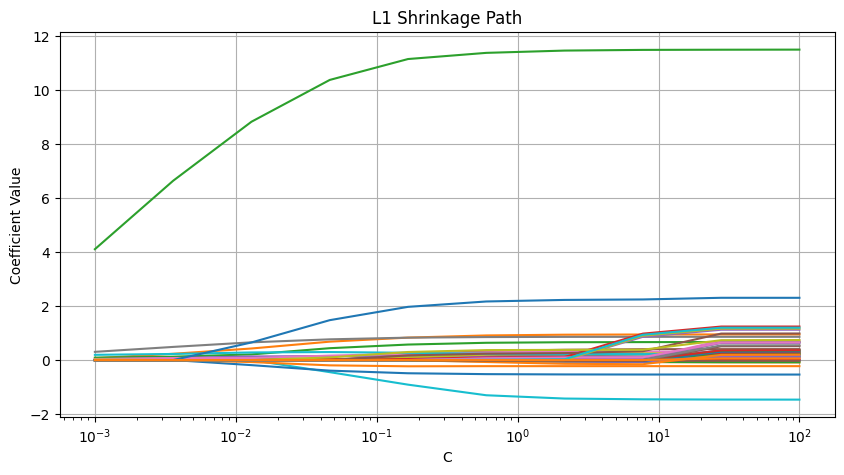

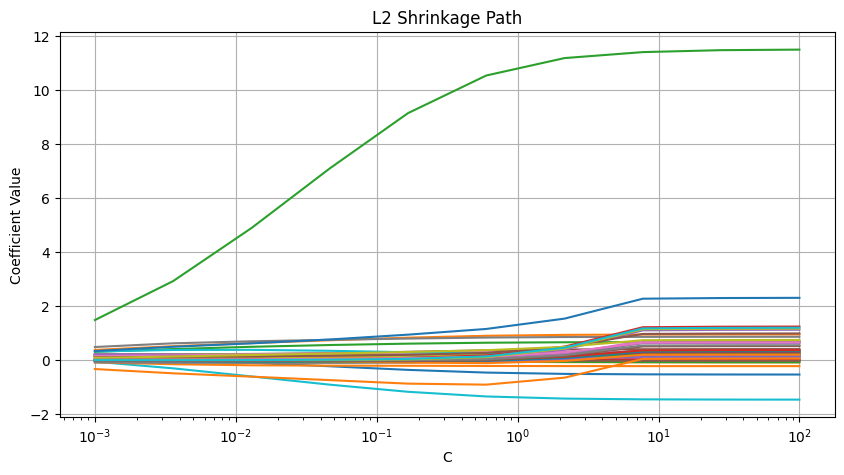

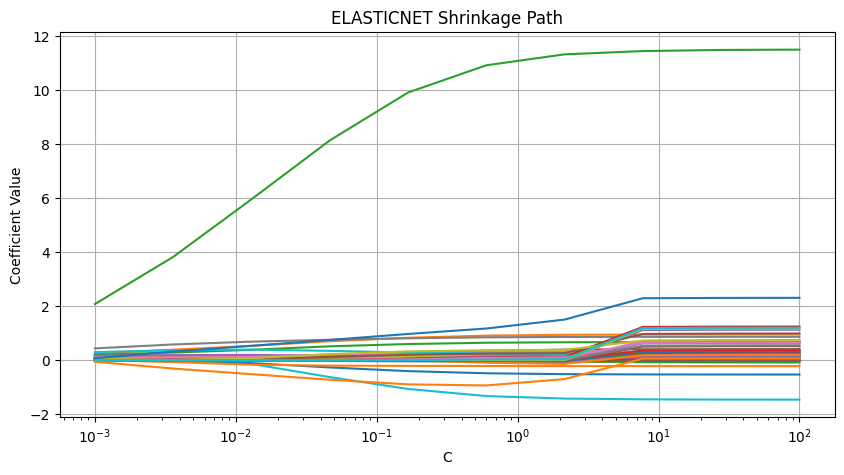

In [ ]:
from sklearn.linear_model import LogisticRegression

C_values = np.logspace(-3, 2, 10)

for penalty in ["l1", "l2", "elasticnet"]:

    coefs = []

    for C in C_values:

        model = LogisticRegression(
            C=C,
            solver="saga",
            penalty=penalty,
            l1_ratio=0.5 if penalty == "elasticnet" else None,
            max_iter=5000,
            random_state=42
        )

        model.fit(X_train_p, y_train)
        coefs.append(model.coef_[0])

    coefs = np.array(coefs)

    plt.figure(figsize=(10, 5))

    for i in range(coefs.shape[1]):
        plt.plot(C_values, coefs[:, i])

    plt.xscale("log")
    plt.xlabel("C")
    plt.ylabel("Coefficient Value")
    plt.title(penalty.upper() + " Shrinkage Path")
    plt.grid()
    plt.show()

C: 0.001 Accuracy: 0.9614
C: 0.01 Accuracy: 0.9926
C: 0.1 Accuracy: 0.9965
C: 1 Accuracy: 0.9968
C: 10 Accuracy: 0.9968
C: 100 Accuracy: 0.9968


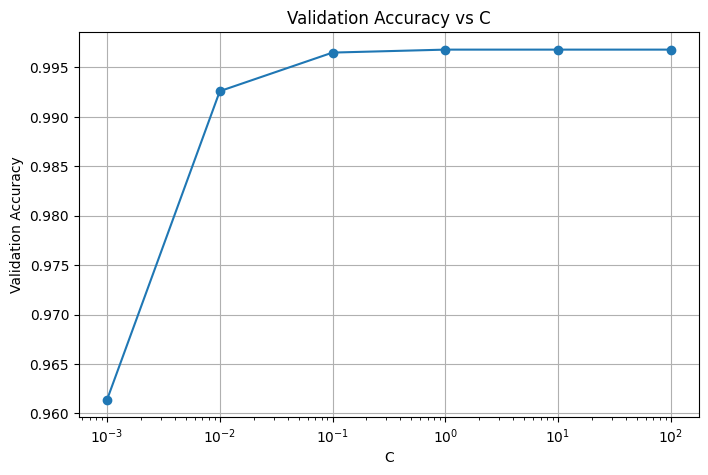

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

accuracies = []

for C in C_values:

    model = LogisticRegression(
        C=C,
        penalty="l2",
        max_iter=2000
    )

    model.fit(X_train_p, y_train)

    accuracy = model.score(X_val_p, y_val)
    accuracies.append(accuracy)

    print("C:", C, "Accuracy:", accuracy)

plt.figure(figsize=(8, 5))
plt.plot(C_values, accuracies, marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.grid()
plt.show()

In [ ]:
results = []

for penalty in ["l1", "l2", "elasticnet"]:

    model = LogisticRegression(
        C=1,
        penalty=penalty,
        solver="saga",
        l1_ratio=0.5 if penalty == "elasticnet" else None,
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_p, y_train)

    count = np.sum(np.abs(model.coef_) > 1e-6)

    print(penalty.upper(),
          "Nonzero Coefficients:", count)

    results.append({
        "Regularisation": penalty.upper(),
        "Nonzero Coefficients": count
    })

print(pd.DataFrame(results))

L1 Nonzero Coefficients: 36
L2 Nonzero Coefficients: 52
ELASTICNET Nonzero Coefficients: 43
  Regularisation  Nonzero Coefficients
0             L1                    36
1             L2                    52
2     ELASTICNET                    43


In [ ]:
def compare_regularisation(X_train, y_train, X_val, y_val):

    results = []

    for penalty in ["l1", "l2", "elasticnet"]:

        model = LogisticRegression(
            C=1,
            penalty=penalty,
            solver="saga",
            l1_ratio=0.5 if penalty == "elasticnet" else None,
            max_iter=5000,
            random_state=42
        )

        model.fit(X_train, y_train)

        accuracy = model.score(X_val, y_val)

        nonzero = np.sum(
            np.abs(model.coef_) > 1e-6
        )

        results.append({
            "Regularisation": penalty.upper(),
            "Validation Accuracy": accuracy,
            "Nonzero Coefficients": nonzero
        })

    return pd.DataFrame(results)


comparison = compare_regularisation(
    X_train_p, y_train,
    X_val_p, y_val
)

print(comparison)

  Regularisation  Validation Accuracy  Nonzero Coefficients
0             L1               0.9968                    36
1             L2               0.9967                    52
2     ELASTICNET               0.9968                    43


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

def compare_regularisation(X_train, y_train, X_val, y_val, C_values):

    results = []

    for C in C_values:

        # Lasso (L1)
        lasso = LogisticRegression(
            penalty="l1", solver="saga",
            C=C, max_iter=5000
        )
        lasso.fit(X_train, y_train)

        lasso_acc = lasso.score(X_val, y_val)
        lasso_nz = np.sum(np.abs(lasso.coef_) > 1e-6)

        # Ridge (L2)
        ridge = LogisticRegression(
            penalty="l2", solver="lbfgs",
            C=C, max_iter=2000
        )
        ridge.fit(X_train, y_train)

        ridge_acc = ridge.score(X_val, y_val)
        ridge_nz = np.sum(np.abs(ridge.coef_) > 1e-6)

        # ElasticNet
        elastic = LogisticRegression(
            penalty="elasticnet", solver="saga",
            C=C, l1_ratio=0.5, max_iter=5000
        )
        elastic.fit(X_train, y_train)

        elastic_acc = elastic.score(X_val, y_val)

        results.append({
            "C": C,
            "Lasso_val_acc": lasso_acc,
            "Ridge_val_acc": ridge_acc,
            "ElasticNet_val_acc": elastic_acc,
            "Lasso_nonzero": lasso_nz,
            "Ridge_nonzero": ridge_nz
        })

    return pd.DataFrame(results)


# Call function
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

result = compare_regularisation(
    X_train_p, y_train,
    X_val_p, y_val,
    C_values
)

print(result)

         C  Lasso_val_acc  Ridge_val_acc  ElasticNet_val_acc  Lasso_nonzero  \
0    0.001         0.9906         0.9614              0.9811              8   
1    0.010         0.9974         0.9926              0.9948             13   
2    0.100         0.9969         0.9965              0.9968             18   
3    1.000         0.9968         0.9968              0.9968             38   
4   10.000         0.9968         0.9968              0.9968             51   
5  100.000         0.9968         0.9968              0.9968             52   

   Ridge_nonzero  
0             52  
1             52  
2             52  
3             52  
4             52  
5             52  
